# Degree Distribution and SF-networks

In [1]:
import networkx as nx
from collections import Counter
import matplotlib.pyplot as plt
from utils import load_graph
import math
import os

The degree $k$ of a node in an undirected graph is the number of edges that are incidental to it, i.e. the number of "neighbors" that is has.

The degree distribution $P(k)$ is the probability distribution of the degrees of the nodes over the whole network.

A scale-free network is a network whose degree distribution follows a power law, at least asymptotically. That is, there is an inverse exponential relation between the number of nodes and degree. On a log-log chart, this manifests as close to a diagonal line.

In plainer language, this means that they typically have a small minority of nodes with $k$ greatly above the average. This increases degree heterogeneity: $\frac{\langle k² \rangle}{\langle k \rangle}$ and places exponentially more importance on hubs as spreaders and blockers in an information cascade.

Some social networks have been shown to be scale-free. Below, we plot the degree distribution of two social networks:

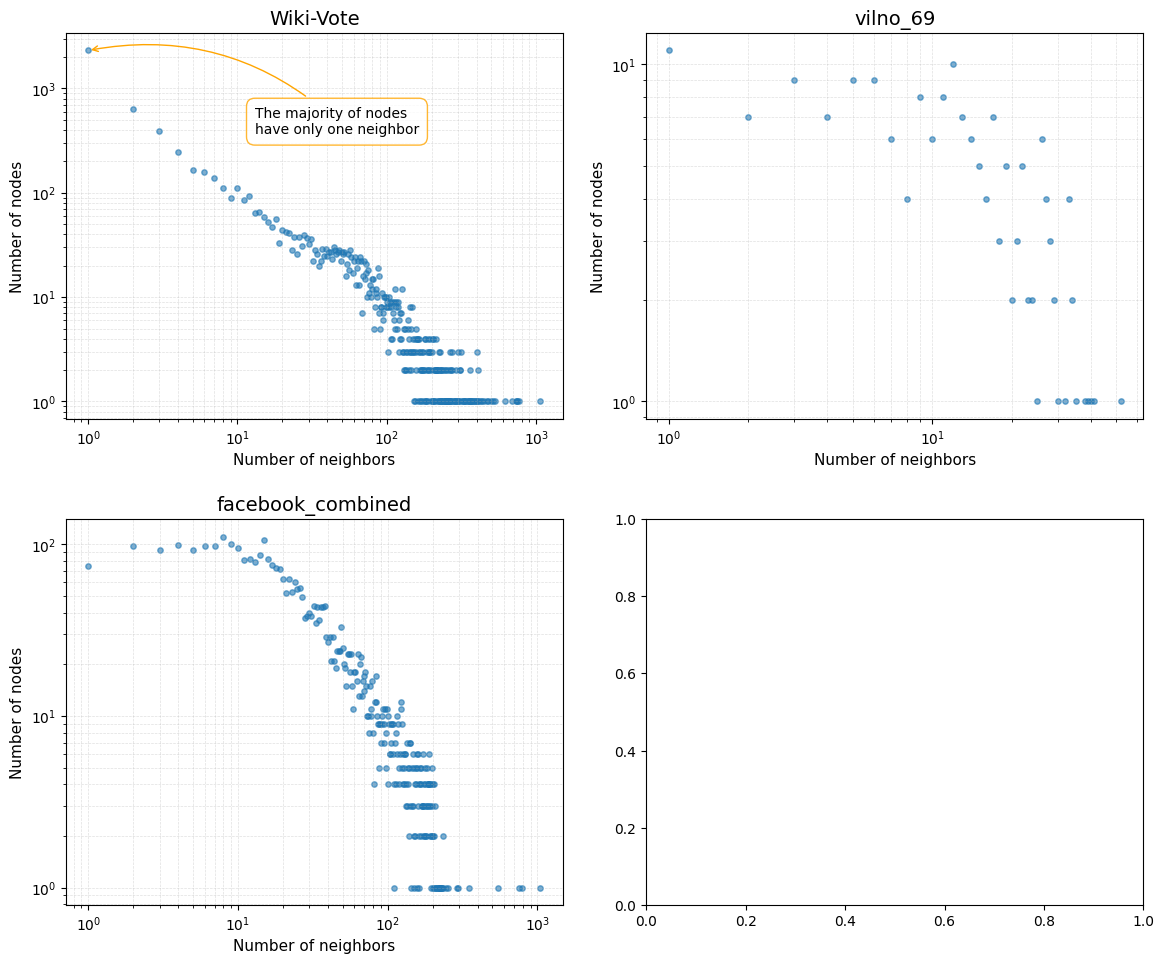

In [3]:
def get_degrees(G):
    degrees = [d for _, d in G.degree()]
    return Counter(degrees)

dir = "data"
files = [f for f in os.listdir(dir)]

n_files = len(files)
n_cols = 2
n_rows = math.ceil(n_files / n_cols)

fig, axes = plt.subplots(n_rows,n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for ax, filename in zip(axes, files):
    path = os.path.join(dir, filename)

    G = load_graph(path)
    degree_counts = get_degrees(G)

    ax.scatter(degree_counts.keys(), degree_counts.values(), s=15, alpha=0.6)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.set_xlabel("Number of neighbors", fontsize=11)
    ax.set_ylabel("Number of nodes", fontsize=11)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(os.path.splitext(filename)[0], fontsize=14)

    if filename.__contains__("Wiki"):
        x1 = 1
        y1 = degree_counts[1]

        ax.annotate(
            "The majority of nodes\nhave only one neighbor",
            xy=(x1, y1),
            xytext=(120,-60),
            textcoords="offset points",
            arrowprops=dict(
                arrowstyle="->",
                color="orange",
                connectionstyle="arc3,rad=0.25",
                linewidth=1
            ),
            bbox=dict(
                boxstyle="round,pad=0.6",
                fc="white",
                ec="orange",
                alpha=0.8
            ),
            fontsize=10
        )

plt.tight_layout(pad=2.0)
plt.show()